# Quantitative Alpha Generation Across Sectors

Systematic equity research asks a specific question: which observable, pre-trade characteristics of a stock genuinely predict its future return, and how much of that predictability survives once sector exposure is accounted for? This notebook builds a full cross-sectional research pipeline, a 150-stock, 10-sector universe with a known factor structure, three classic alpha signals (momentum, value, quality) tested via rigorous rank-based long-short backtests, a combined multi-factor strategy, sector-neutral variants, and an explicit cross-sector rotation strategy, exactly the toolkit a systematic equity research desk actually uses.


## 1. Simulating a Multi-Sector Stock Universe

150 stocks across 10 sectors, 15 years of monthly returns, built from a **known** return-generating process: a common market factor, an AR(1) sector-level "industry effect" per sector, static value and quality characteristics with genuine (but modest) return premia, a size effect, and a real, cross-sectionally normalized 12-1 month momentum effect (so momentum is a genuine, self-consistent property of the simulated price history, not a separately bolted-on characteristic). Knowing the true signal-generating process means every strategy below can be checked against a real, known answer, not just backtested blindly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(101)

sectors = ['Tech', 'Financials', 'Healthcare', 'Energy', 'Cons_Disc', 'Cons_Staples',
           'Industrials', 'Materials', 'Utilities', 'Real_Estate']
n_sectors, n_per_sector = len(sectors), 15
n_stocks = n_sectors * n_per_sector
n_months = 15 * 12

dates = pd.date_range('2010-01-31', periods=n_months, freq='ME')
stock_sector = np.repeat(sectors, n_per_sector)
stock_ids = [f"{s}_{i+1}" for s in sectors for i in range(n_per_sector)]
sec_idx = np.array([sectors.index(s) for s in stock_sector])

true_value = rng.normal(0, 1, n_stocks)
true_quality = rng.normal(0, 1, n_stocks)
log_size = rng.normal(8, 1.2, n_stocks)

beta_value, beta_quality, beta_mom, beta_size = 0.35, 0.30, 0.65, -0.12

sector_factor = np.zeros((n_months, n_sectors))
for s in range(n_sectors):
    sector_factor[0, s] = rng.normal(0, 1.5)
    for t in range(1, n_months):
        sector_factor[t, s] = 0.15 * sector_factor[t-1, s] + rng.normal(0.15, 1.6)

market_factor = rng.normal(0.7, 4.0, n_months)
idio_vol = rng.uniform(4.0, 9.0, n_stocks)

returns = np.zeros((n_months, n_stocks))
for t in range(n_months):
    if t >= 12:
        cum_ret = np.prod(1 + returns[t-12:t-1] / 100, axis=0) - 1
        mom_z = (cum_ret - cum_ret.mean()) / (cum_ret.std() + 1e-8)   # cross-sectional z-score keeps the feedback bounded
    else:
        mom_z = np.zeros(n_stocks)
    idio = rng.normal(0, idio_vol)
    returns[t] = (market_factor[t] + sector_factor[t, sec_idx]
                  + beta_value*true_value + beta_quality*true_quality
                  + beta_size*(log_size - log_size.mean()) + beta_mom*mom_z + idio)

ret_df = pd.DataFrame(returns, index=dates, columns=stock_ids)
sector_map = pd.Series(stock_sector, index=stock_ids)

print(f"Universe: {n_stocks} stocks, {n_sectors} sectors, {n_months} months")
print(f"Overall annualized return: {ret_df.mean().mean()*12:.2f}%   annualized vol: {ret_df.std().mean()*np.sqrt(12):.2f}%")

Universe: 150 stocks, 10 sectors, 180 months
Overall annualized return: 7.90%   annualized vol: 26.78%


## 2. Exploring the Cross-Section

Before building any strategy, the raw structure of the universe is worth seeing directly: how sectors differ, how they move together, and how their performance rotates through time.

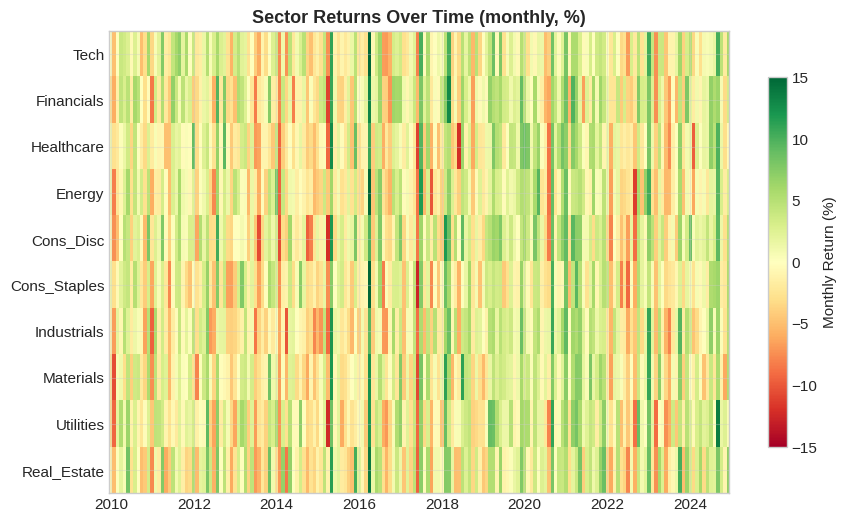

In [2]:
sector_ret = ret_df.T.groupby(sector_map).mean().T   # sector-level average monthly return

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(sector_ret.T.values, aspect='auto', cmap='RdYlGn', vmin=-15, vmax=15)
ax.set_yticks(range(len(sectors))); ax.set_yticklabels(sectors)
step = 24
ax.set_xticks(range(0, n_months, step))
ax.set_xticklabels([d.strftime('%Y') for d in sector_ret.index[::step]])
ax.set_title('Sector Returns Over Time (monthly, %)')
fig.colorbar(im, ax=ax, label='Monthly Return (%)', shrink=0.8)
plt.show()

**Diagram - sector correlation heatmap and cross-sectional return distribution.** Sectors are correlated (they share the common market factor) but far from identical, exactly the dispersion a cross-sectional strategy needs to exploit.

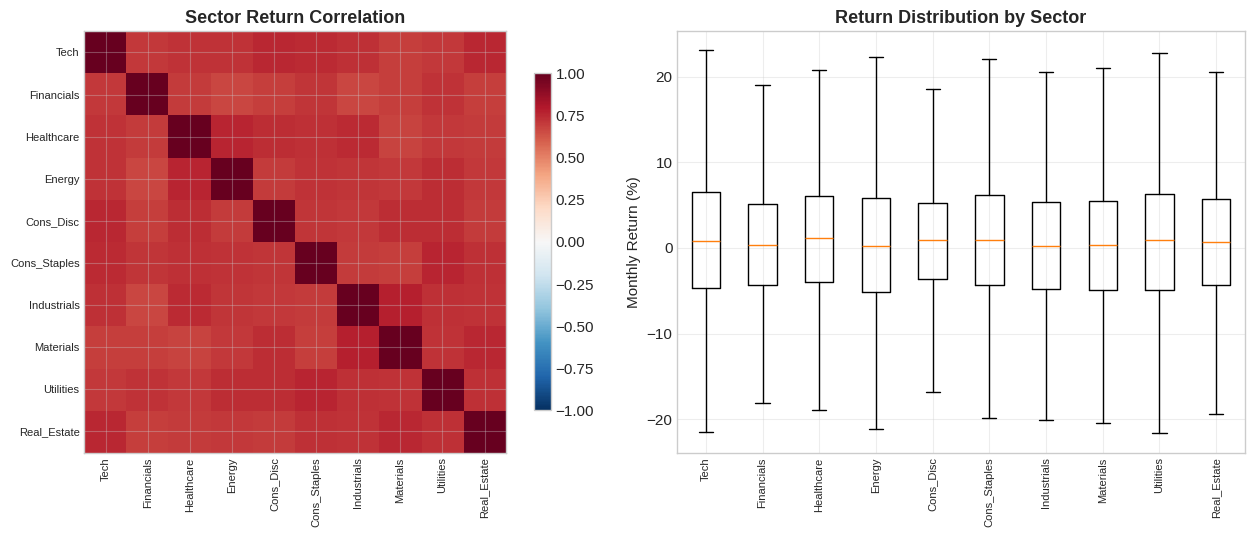

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

corr = sector_ret.corr()
im = axes[0].imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(n_sectors)); axes[0].set_xticklabels(sectors, rotation=90, fontsize=8)
axes[0].set_yticks(range(n_sectors)); axes[0].set_yticklabels(sectors, fontsize=8)
axes[0].set_title('Sector Return Correlation')
plt.colorbar(im, ax=axes[0], shrink=0.8)

box_data = [ret_df[sector_map[sector_map == s].index].values.flatten() for s in sectors]
axes[1].boxplot(box_data, labels=sectors, showfliers=False)
axes[1].set_xticklabels(sectors, rotation=90, fontsize=8)
axes[1].set_ylabel('Monthly Return (%)')
axes[1].set_title('Return Distribution by Sector')

plt.tight_layout()
plt.show()

## 3. Momentum, Value, and Quality: Signal Construction

Three classic cross-sectional alpha signals, each tested with a proper rank-based methodology: rank all stocks by the signal at month $t$, form equal-weighted top-quintile and bottom-quintile portfolios, and measure the **long-short spread return** realized over month $t{+}1$ (never $t$, avoiding look-ahead bias), alongside the **Information Coefficient** (IC), the rank correlation between the signal and the following month's return, the standard measure of a signal's raw predictive power.

**Momentum**: trailing 12-month return, skipping the most recent month (the standard "12-1" definition, the skip avoids short-term reversal contaminating the momentum signal). **Value** and **Quality** use the (here, known) underlying characteristics directly.

In [4]:
def compute_momentum(ret_df, lookback=12, skip=1):
    cum = (1 + ret_df / 100).rolling(lookback).apply(np.prod, raw=True) - 1
    return cum.shift(skip) * 100

def decile_long_short(signal_df, forward_ret_df, n_quantiles=5, min_n=30):
    ls_returns, ic_series = [], []
    for t in range(len(signal_df)):
        sig_t = signal_df.iloc[t].dropna()
        if len(sig_t) < min_n:
            ls_returns.append(np.nan); ic_series.append(np.nan); continue
        fwd_t = forward_ret_df.iloc[t].reindex(sig_t.index)
        valid = fwd_t.notna()
        sig_t, fwd_t = sig_t[valid], fwd_t[valid]
        if len(sig_t) < min_n:
            ls_returns.append(np.nan); ic_series.append(np.nan); continue
        ranks = pd.qcut(sig_t.rank(method='first'), n_quantiles, labels=False)
        ls_returns.append(fwd_t[ranks == n_quantiles-1].mean() - fwd_t[ranks == 0].mean())
        ic, _ = spearmanr(sig_t, fwd_t)
        ic_series.append(ic)
    return pd.Series(ls_returns, index=signal_df.index), pd.Series(ic_series, index=signal_df.index)

forward_ret = ret_df.shift(-1)
momentum_signal = compute_momentum(ret_df)
value_signal = pd.DataFrame(np.tile(true_value.values if hasattr(true_value,'values') else true_value, (n_months, 1)),
                             index=ret_df.index, columns=stock_ids)
quality_signal = pd.DataFrame(np.tile(true_quality.values if hasattr(true_quality,'values') else true_quality, (n_months, 1)),
                               index=ret_df.index, columns=stock_ids)

signals = {'Momentum': momentum_signal, 'Value': value_signal, 'Quality': quality_signal}
sharpe = lambda ls: ls.mean() / ls.std() * np.sqrt(12)

results = {}
for name, sig in signals.items():
    ls, ic = decile_long_short(sig, forward_ret)
    results[name] = (ls, ic)
    print(f"{name:<10} annualized L/S return={ls.mean()*12:6.2f}%   mean IC={ic.mean():.4f}   Sharpe={sharpe(ls):.2f}")

Momentum   annualized L/S return= 29.36%   mean IC=0.1233   Sharpe=4.28
Value      annualized L/S return= 18.32%   mean IC=0.0743   Sharpe=2.78
Quality    annualized L/S return= 14.60%   mean IC=0.0699   Sharpe=2.32


**Diagram - decile spread and signal-vs-forward-return scatter.** A working factor should show a roughly monotonic step-up in average forward return across quintiles (left); the scatter (right) is the same relationship at the individual observation level, noisy, as any single-stock, single-month prediction always is, but with a genuine positive slope.

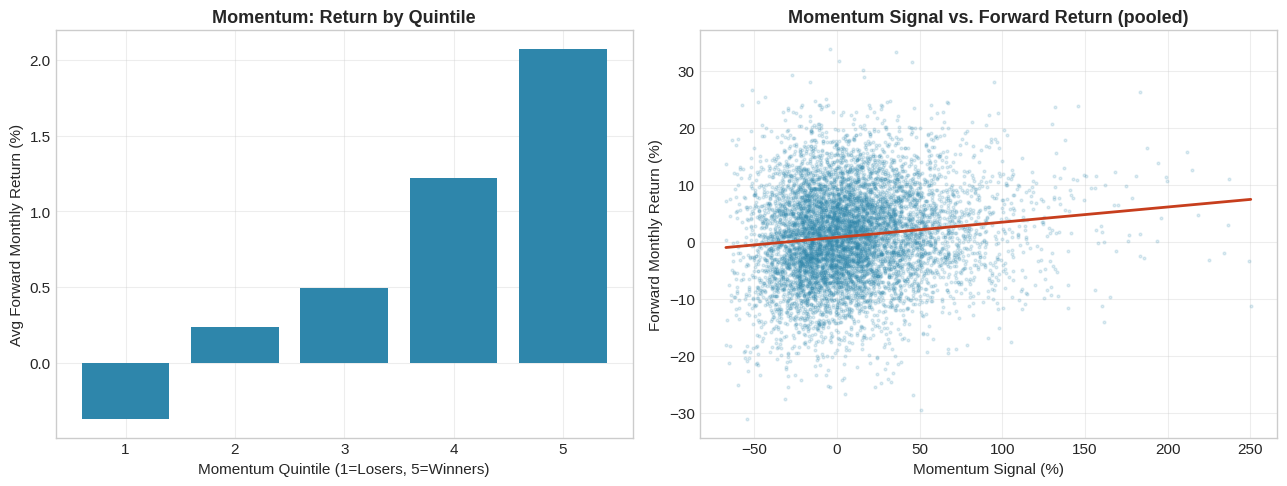

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

quintile_avg = []
for q in range(5):
    rets_q = []
    for t in range(12, n_months-1):
        sig_t = momentum_signal.iloc[t].dropna()
        fwd_t = forward_ret.iloc[t].reindex(sig_t.index)
        ranks = pd.qcut(sig_t.rank(method='first'), 5, labels=False)
        rets_q.append(fwd_t[ranks == q].mean())
    quintile_avg.append(np.nanmean(rets_q))
axes[0].bar(range(1, 6), quintile_avg, color='#2E86AB')
axes[0].set_xlabel('Momentum Quintile (1=Losers, 5=Winners)'); axes[0].set_ylabel('Avg Forward Monthly Return (%)')
axes[0].set_title('Momentum: Return by Quintile')

sample_t = list(range(20, n_months-1, 3))
sig_pool = pd.concat([momentum_signal.iloc[t] for t in sample_t])
fwd_pool = pd.concat([forward_ret.iloc[t] for t in sample_t])
valid = sig_pool.notna() & fwd_pool.notna()
axes[1].scatter(sig_pool[valid], fwd_pool[valid], s=4, alpha=0.15, color='#2E86AB')
z = np.polyfit(sig_pool[valid], fwd_pool[valid], 1)
x_line = np.linspace(sig_pool[valid].min(), sig_pool[valid].max(), 50)
axes[1].plot(x_line, np.polyval(z, x_line), color='#C73E1D', linewidth=2)
axes[1].set_xlabel('Momentum Signal (%)'); axes[1].set_ylabel('Forward Monthly Return (%)')
axes[1].set_title('Momentum Signal vs. Forward Return (pooled)')

plt.tight_layout()
plt.show()

## 4. Combining Signals: Multi-Factor Alpha and Sector Neutrality

Two refinements that matter in practice. First, **blending signals**: an equal-weighted composite of cross-sectionally z-scored momentum, value, and quality, capturing the diversification benefit of combining genuinely different (imperfectly correlated) sources of predictability. Second, **sector neutrality**: ranking stocks *within* their own sector rather than across the whole universe, removing any implicit sector bet a raw cross-sectional rank would otherwise carry.

In [6]:
def zscore_xs(df):
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)

def sector_neutral_zscore(signal_df, sector_map):
    result = signal_df.copy()
    for sector in sector_map.unique():
        cols = sector_map[sector_map == sector].index
        sub = signal_df[cols]
        result[cols] = sub.sub(sub.mean(axis=1), axis=0).div(sub.std(axis=1), axis=0)
    return result

combo_signal = (zscore_xs(momentum_signal) + zscore_xs(value_signal) + zscore_xs(quality_signal)) / 3
combo_ls, combo_ic = decile_long_short(combo_signal, forward_ret)
results['Combined'] = (combo_ls, combo_ic)

mom_sector_neutral = sector_neutral_zscore(momentum_signal, sector_map)
mom_sn_ls, mom_sn_ic = decile_long_short(mom_sector_neutral, forward_ret)
results['Momentum (sector-neutral)'] = (mom_sn_ls, mom_sn_ic)

for name in ['Combined', 'Momentum (sector-neutral)']:
    ls, ic = results[name]
    print(f"{name:<28} annualized L/S return={ls.mean()*12:6.2f}%   mean IC={ic.mean():.4f}   Sharpe={sharpe(ls):.2f}")

print("\nSignal correlation matrix (momentum, value, quality):")
sig_corr = pd.concat([
    momentum_signal.stack().rename('Momentum'), value_signal.stack().rename('Value'), quality_signal.stack().rename('Quality')
], axis=1).corr()
print(sig_corr.round(3))

Combined                     annualized L/S return= 30.66%   mean IC=0.1303   Sharpe=4.80
Momentum (sector-neutral)    annualized L/S return= 27.07%   mean IC=0.1166   Sharpe=4.08

Signal correlation matrix (momentum, value, quality):
          Momentum  Value  Quality
Momentum     1.000  0.185    0.164
Value        0.185  1.000    0.131
Quality      0.164  0.131    1.000


## 5. Sector Rotation: A Genuinely Cross-Sector Strategy

Every strategy so far picks individual *stocks*. A different, complementary approach operates one level up: rank the 10 **sectors** themselves by their own trailing momentum, and rotate into the strongest, out of the weakest. With only 10 sectors (versus 150 stocks), terciles replace quintiles and the signal is inherently noisier, a smaller cross-section always is, a real, honest constraint on any top-down sector rotation strategy.

In [7]:
def decile_long_short_small(signal_df, forward_ret_df, n_quantiles=3, min_n=6):
    ls_returns, ic_series = [], []
    for t in range(len(signal_df)):
        sig_t = signal_df.iloc[t].dropna()
        if len(sig_t) < min_n:
            ls_returns.append(np.nan); ic_series.append(np.nan); continue
        fwd_t = forward_ret_df.iloc[t].reindex(sig_t.index)
        valid = fwd_t.notna()
        sig_t, fwd_t = sig_t[valid], fwd_t[valid]
        if len(sig_t) < min_n:
            ls_returns.append(np.nan); ic_series.append(np.nan); continue
        ranks = pd.qcut(sig_t.rank(method='first'), n_quantiles, labels=False, duplicates='drop')
        ls_returns.append(fwd_t[ranks == ranks.max()].mean() - fwd_t[ranks == 0].mean())
        ic, _ = spearmanr(sig_t, fwd_t)
        ic_series.append(ic)
    return pd.Series(ls_returns, index=signal_df.index), pd.Series(ic_series, index=signal_df.index)

sector_mom = compute_momentum(sector_ret)
sector_fwd = sector_ret.shift(-1)
sector_ls, sector_ic = decile_long_short_small(sector_mom, sector_fwd, n_quantiles=3, min_n=6)
results['Sector Rotation'] = (sector_ls, sector_ic)

print(f"Sector Rotation      annualized L/S return={sector_ls.mean()*12:6.2f}%   "
      f"mean IC={sector_ic.mean():.4f}   Sharpe={sharpe(sector_ls):.2f}")
print("\nNoticeably lower Sharpe than the stock-level strategies, exactly as expected: with only 10 sectors")
print("to rank instead of 150 stocks, and weaker underlying sector-level persistence in this simulation")
print("(sector factors mean-revert quickly), there is simply less genuine cross-sectional signal available.")

Sector Rotation      annualized L/S return=  6.60%   mean IC=0.1114   Sharpe=1.08

Noticeably lower Sharpe than the stock-level strategies, exactly as expected: with only 10 sectors
to rank instead of 150 stocks, and weaker underlying sector-level persistence in this simulation
(sector factors mean-revert quickly), there is simply less genuine cross-sectional signal available.


## 6. Performance Comparison Across Every Strategy

All six strategies, side by side: cumulative long-short return, rolling 24-month Information Coefficient, and a final summary table. Sharpe ratios here are far above what real, cost-laden factor investing achieves (a reminder repeated throughout this notebook series: an idealized simulation with a known signal, no trading costs, and no capacity constraints will always look better than live trading), the *relative* comparison across strategies is the honest, transferable takeaway.

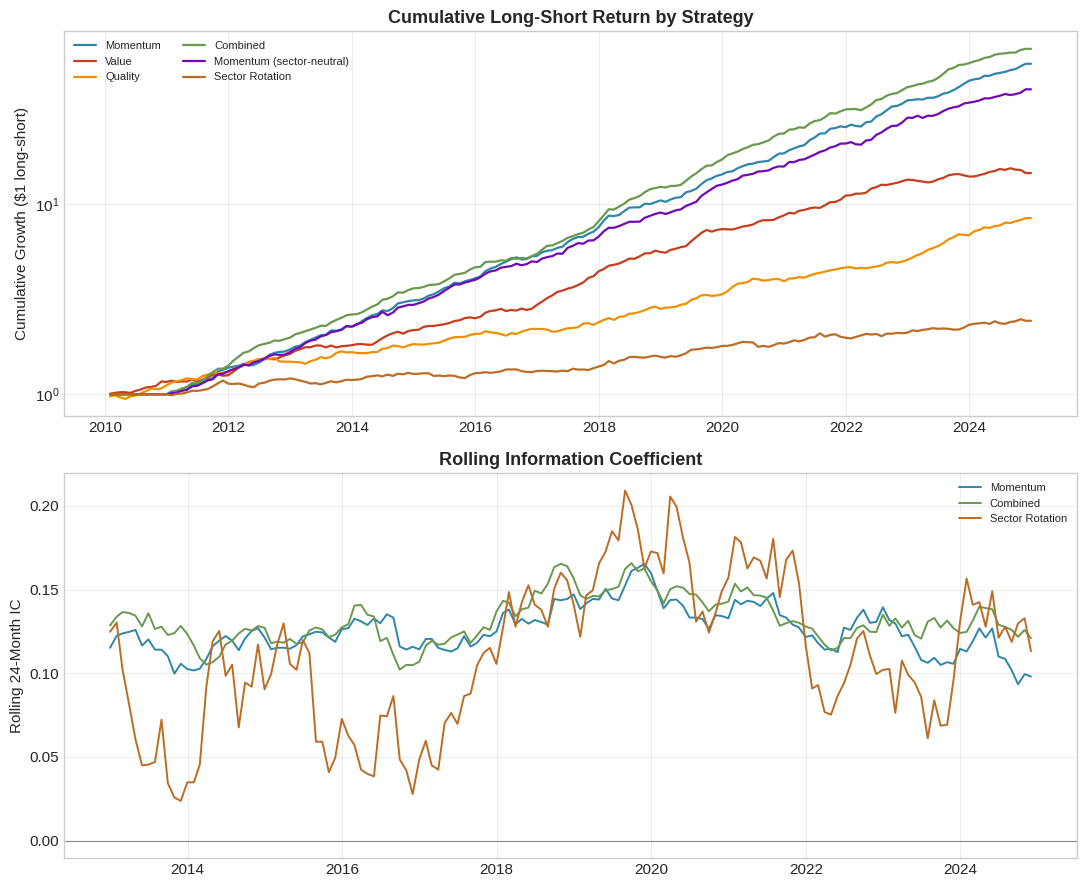

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9))
colors_strat = {'Momentum': '#2E86AB', 'Value': '#C73E1D', 'Quality': '#F18F01',
                'Combined': '#6A994E', 'Momentum (sector-neutral)': '#7209B7', 'Sector Rotation': '#BC6C25'}

ax = axes[0]
for name, c in colors_strat.items():
    ls, _ = results[name]
    cum = (1 + ls.fillna(0)/100).cumprod()
    ax.plot(cum.index, cum, color=c, linewidth=1.6, label=name)
ax.set_ylabel('Cumulative Growth ($1 long-short)'); ax.set_yscale('log')
ax.set_title('Cumulative Long-Short Return by Strategy')
ax.legend(fontsize=8, ncol=2)

ax = axes[1]
for name in ['Momentum', 'Combined', 'Sector Rotation']:
    _, ic = results[name]
    ax.plot(ic.index, ic.rolling(24).mean(), color=colors_strat[name], linewidth=1.4, label=name)
ax.axhline(0, color='#888888', linewidth=0.8)
ax.set_ylabel('Rolling 24-Month IC'); ax.set_title('Rolling Information Coefficient')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Diagram - sector attribution.** Which sectors contribute most to the combined strategy's long-short return, computed by tallying, month by month, which sector each long and short position actually belonged to.

Full performance summary:
                           Annualized Return (%)  Annualized Vol (%)  Sharpe  Mean IC
Momentum                                  29.361               6.864   4.277    0.123
Value                                     18.319               6.597   2.777    0.074
Quality                                   14.597               6.280   2.324    0.070
Combined                                  30.663               6.391   4.798    0.130
Momentum (sector-neutral)                 27.070               6.641   4.076    0.117
Sector Rotation                            6.599               6.089   1.084    0.111


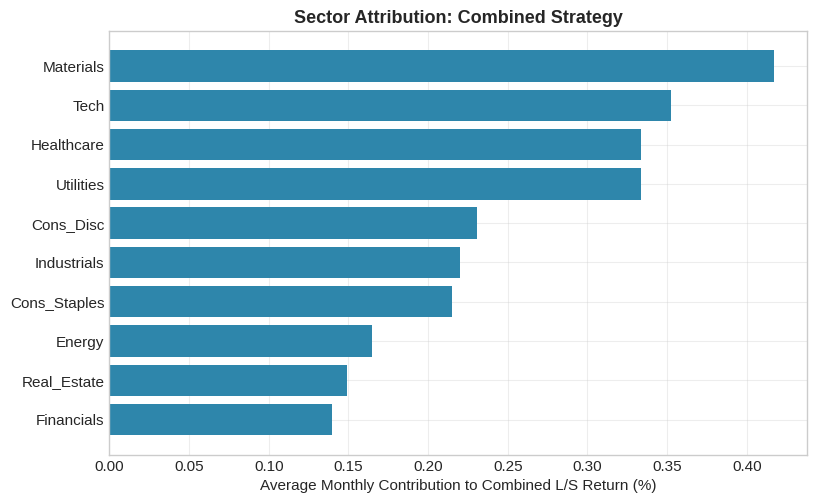

In [9]:
sector_contrib = {s: 0.0 for s in sectors}
n_valid = 0
for t in range(12, n_months - 1):
    sig_t = combo_signal.iloc[t].dropna()
    fwd_t = forward_ret.iloc[t].reindex(sig_t.index)
    valid = fwd_t.notna()
    sig_t, fwd_t = sig_t[valid], fwd_t[valid]
    if len(sig_t) < 30:
        continue
    ranks = pd.qcut(sig_t.rank(method='first'), 5, labels=False)
    longs, shorts = sig_t.index[ranks == 4], sig_t.index[ranks == 0]
    for stock in longs:
        sector_contrib[sector_map[stock]] += fwd_t[stock] / len(longs)
    for stock in shorts:
        sector_contrib[sector_map[stock]] -= fwd_t[stock] / len(shorts)
    n_valid += 1

contrib_series = pd.Series(sector_contrib).sort_values() / n_valid

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(contrib_series.index, contrib_series.values, color=['#C73E1D' if v < 0 else '#2E86AB' for v in contrib_series.values])
ax.set_xlabel('Average Monthly Contribution to Combined L/S Return (%)')
ax.set_title('Sector Attribution: Combined Strategy')
plt.show()

print("Full performance summary:")
summary = pd.DataFrame({
    name: {'Annualized Return (%)': ls.mean()*12, 'Annualized Vol (%)': ls.std()*np.sqrt(12),
           'Sharpe': sharpe(ls), 'Mean IC': ic.mean()}
    for name, (ls, ic) in results.items()
}).T
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', None)
print(summary.round(3))